In [1]:
import numpy as np
import pandas as pd
from shapely.geometry import Polygon, LineString, Point
from shapely.ops import nearest_points
import matplotlib.pyplot as plt
import os
import tqdm # For progress bars

# Assuming these are in your data_simulations.py
from data_simulations import (
    TissueCellTypes,
    CellTypesProperties,
    HybISS_Setup,
    FOV,
    FOVDistribution,
    TissueSlice,
    ProbabilityNodeFieldRule,
    SingleTypeRule,
    MixOfNCellTypesRule,
    FrameWideElement,
    VacuolatedStructure,
    HistologicalElement,
    IdentityTransfer,
    RegionSpec # Ensure this is in your imports
)

# =========================================================================
#  GLOBAL PARAMETERS
# =========================================================================
GLOBAL_WIDTH = 800
GLOBAL_HEIGHT = 1000
FRAME_SIZE = max(GLOBAL_HEIGHT, GLOBAL_WIDTH)
N_CELL_TYPES = 15 # Total cell types for all skin structures

# --- Assumed Cell Type IDs ---
ID_KERATINOCYTE = 0 # Top layer of epidermis
ID_BASAL_CELL = 1   # Bottom layer of epidermis
ID_FIBROBLAST = 2   # Dermis background (stroma)
ID_IMMUNE = 3       # Immune cells (e.g., T-cells in dermis)
ID_FOLLICLE_A = 4   # Hair follicle cell type A
ID_FOLLICLE_B = 5   # Hair follicle cell type B
ID_GLAND_A = 6      # Sebaceous gland cell type
ID_ENDOTHELIAL = 7  # Blood vessel cells
# ... other types up to N_CELL_TYPES-1

# =========================================================================
#  HELPER FUNCTION FOR WAVY POLYGONS (from your cortex/colon code)
# =========================================================================
def make_wavy_poly(x_start, x_end, y_start, y_end, waviness=30, n_points=20):
    """Helper to make a polygon with wavy vertical edges."""
    # Left wavy edge
    y_left = np.linspace(y_start, y_end, n_points)
    x_left = np.random.normal(x_start, waviness/3, n_points)
    x_left = np.clip(x_left, x_start - waviness, x_start + waviness)
    left_edge = list(zip(x_left, y_left))
    
    # Right wavy edge
    y_right = np.linspace(y_end, y_start, n_points) # Go back up
    x_right = np.random.normal(x_end, waviness/3, n_points)
    x_right = np.clip(x_right, x_end - waviness, x_end + waviness)
    right_edge = list(zip(x_right, y_right))
    
    # Combine
    poly = Polygon(left_edge + right_edge)
    return poly.buffer(0) # Clean up self-intersections

# =========================================================================
#  RECIPE 1: EPIDERMIS (The top layer)
# =========================================================================

# --- Define the Epidermal Gradient ---
# We'll use 6 points (3 top, 3 bottom) to create a stable vertical gradient
# Zone 1 (Top): Keratinocytes
prob_epidermis_top = np.zeros(N_CELL_TYPES)
prob_epidermis_top[ID_KERATINOCYTE] = 1.0

# Zone 2 (Bottom): Basal Cells
prob_epidermis_bottom = np.zeros(N_CELL_TYPES)
prob_epidermis_bottom[ID_BASAL_CELL] = 1.0

epidermis_rules = [
    ProbabilityNodeFieldRule(
        n_cell_types=N_CELL_TYPES,
        n_ref_points=6,
        reference_points=np.array([
            # --- Top reference points (at y=10) ---
            [GLOBAL_WIDTH * 0.1, 10],  
            [GLOBAL_WIDTH * 0.5, 10],
            [GLOBAL_WIDTH * 0.9, 10],
            # --- Bottom reference points (at y=140) ---
            [GLOBAL_WIDTH * 0.1, 140], 
            [GLOBAL_WIDTH * 0.5, 140],
            [GLOBAL_WIDTH * 0.9, 140],
        ]),
        ref_probs=np.array([
            prob_epidermis_top,
            prob_epidermis_top,
            prob_epidermis_top,
            prob_epidermis_bottom,
            prob_epidermis_bottom,
            prob_epidermis_bottom,
        ])
    )
]

EpidermisPrototype = lambda: FrameWideElement(frame_size=FRAME_SIZE,
                                              tipical_cell_spacing=6, # Very Dense
                                              rules=epidermis_rules)

# --- Define the FOV Distribution for the Epidermis ---
fovd_epidermis = FOVDistribution(frame_size=FRAME_SIZE,
                                 background_element=EpidermisPrototype,
                                 other_elements=[],
                                 elements_frequency=[],
                                 attempts_at_elements=0)

# =========================================================================
#  RECIPE 2: DERMIS (The main structural layer)
# =========================================================================

# --- Dermis Background: Sparse fibroblasts and immune cells ---
dermis_bg_rules = [
    MixOfNCellTypesRule(N_CELL_TYPES, 
                        list_N=[ID_FIBROBLAST, ID_IMMUNE],
                        proportions=[0.9, 0.1])
]
DermisPrototype = lambda: FrameWideElement(frame_size=FRAME_SIZE,
                                           tipical_cell_spacing=12, # Less dense
                                           rules=dermis_bg_rules)

# --- Dermis Embedded Elements ---

# Prototype 1: Hair Follicle (long, dense, multi-type)
def FolliclePrototype():
    # Spawn somewhere in the upper/mid dermis
    center = np.array([np.random.uniform(100, GLOBAL_WIDTH - 100), 
                       np.random.uniform(250, 600)])
    scale = np.random.uniform(150, 250) # Long and thin
    rules = [MixOfNCellTypesRule(N_CELL_TYPES, list_N=[ID_FOLLICLE_A, ID_FOLLICLE_B], proportions=[0.6, 0.4])]
    return HistologicalElement(frame_size=FRAME_SIZE,
                               scale=scale,
                               fixed_center=center,
                               rules=rules,
                               n_vertices=(7, 10), # Irregular shape
                               tipical_cell_spacing=5) # Very dense

# Prototype 2: Sebaceous Gland (blobby, vacuolated, single-type)
def GlandPrototype():
    # Spawn near the follicles
    center = np.array([np.random.uniform(100, GLOBAL_WIDTH - 100), 
                       np.random.uniform(200, 500)])
    scale = np.random.uniform(60, 100)
    rules = [SingleTypeRule(N_CELL_TYPES, cell_type_ix=ID_GLAND_A)]
    return VacuolatedStructure(frame_size=FRAME_SIZE,
                               scale=scale,
                               fixed_center=center,
                               rules=rules,
                               tipical_cell_spacing=6, # Dense
                               hole_scale_factor=np.random.uniform(0.3, 0.6))

# Prototype 3: Blood Vessel (small, circular, endothelial)
def VesselPrototype():
    center = np.array([np.random.uniform(50, GLOBAL_WIDTH - 50), 
                       np.random.uniform(200, GLOBAL_HEIGHT - 50)])
    scale = np.random.uniform(20, 40)
    rules = [SingleTypeRule(N_CELL_TYPES, cell_type_ix=ID_ENDOTHELIAL)]
    return HistologicalElement(frame_size=FRAME_SIZE,
                               scale=scale,
                               fixed_center=center,
                               rules=rules,
                               n_vertices=(8, 12), # Make it roughly circular
                               tipical_cell_spacing=6)

# --- Define the FOV Distribution for the Dermis ---
fovd_dermis = FOVDistribution(frame_size=FRAME_SIZE,
                              background_element=DermisPrototype,
                              other_elements=[FolliclePrototype, GlandPrototype, VesselPrototype],
                              elements_frequency=[1.0, 1.0, 1.0], # Always try to add
                              attempts_at_elements=[5, 4, 15]) # 5 follicles, 4 glands, 15 vessels

# =========================================================================
#  REGION DEFINITIONS
# =========================================================================

# R1: The Epidermis (Top, wavy)
# We use a wavy polygon for the *bottom* boundary
R1_Epidermis_Poly = make_wavy_poly(
    x_start=0, x_end=GLOBAL_WIDTH, 
    y_start=0, y_end=150, # Average thickness of 150
    waviness=30, n_points=50 # Add waviness
)

# R2: The Dermis (Fills everything below the epidermis)
# We create a wavy polygon that overlaps slightly to ensure no gaps
R2_Dermis_Poly = make_wavy_poly(
    x_start=0, x_end=GLOBAL_WIDTH, 
    y_start=130, y_end=GLOBAL_HEIGHT, # Overlap by 20px
    waviness=30, n_points=50
)

# --- Assemble the Tissue Slice ---
all_regions = []

# --- Priority 0: The Base Dermis ---
# This layer is drawn first. It contains the stroma + all its embedded elements.
all_regions.append(RegionSpec(
    name="Dermis",
    polygon=R2_Dermis_Poly,
    fovdist=fovd_dermis,
    priority=0,
    blend_band=20.0 
))

# --- Priority 1: The Epidermis ---
# This layer is drawn ON TOP of the dermis, carving out its space.
all_regions.append(RegionSpec(
    name="Epidermis",
    polygon=R1_Epidermis_Poly,
    fovdist=fovd_epidermis,
    priority=1,
    blend_band=10.0
))

# --- Create the Tissue Slice ---
print("Creating tissue slice...")
tissue_slice = TissueSlice(frame_size=FRAME_SIZE, regions=all_regions)

# =========================================================================
#  MAIN SCRIPT EXECUTION
# =========================================================================

# 1. Create the master "Tissue" (gene expression table)
print("Initializing tissue and experiment...")
tissue = TissueCellTypes()
tissue.generate_types_and_markers(
    n_genes=50,
    n_cell_types=N_CELL_TYPES,
    expected_level=50.0,
    expected_std_level=5.0,
    concentration=0.9 # Keep marker genes relatively distinct
)

# Create output directories
os.makedirs('output_skin/data', exist_ok=True)
os.makedirs('output_skin/parameters', exist_ok=True)
os.makedirs('output_skin/ground_truths', exist_ok=True)

cell_type_df = tissue.make_pandas_df()
cell_type_df.to_csv('output_skin/parameters/cell_types.csv')

# 2. Create the "Cell Properties" object
cell_props = CellTypesProperties(
    n_cell_types=N_CELL_TYPES,
    sizes=12,
    size_variation=0.2,
    anisotropy=1.5,
    anisotropy_variation=0.3,
    relative_rna_concentration=1.0,
    rna_concentration_variation=0.05
)

# 3. Create the "HybISS Experiment" simulator
hybISS = HybISS_Setup(
    tissue,
    genes_sensitivities=1.0,
    genes_sensitivities_variation=0.1,
    transfer_function=IdentityTransfer()
)
print("Tissue and experiment initialized.")

# --- 1. Generate the Global Master Tissue ---
print("Generating global tissue... this may take a while.")
tissue_slice.generate_global()
tissue_slice.sample_labels() # Assign hard labels

print(f"Generated {len(tissue_slice._cells_xy)} total cells.")

# --- 1b. Generate and Save Full Tissue Data (Global) ---
print("Generating global data for the full tissue slice...")
global_fov = FOV(
    cell_centroids=tissue_slice._cells_xy,
    cell_probabilities=tissue_slice._probs
)
global_fov.class_instance_one_hot = tissue_slice._class_onehot

print("Applying cell properties to global data...")
cell_props.apply(global_fov)

print("Simulating dots for global data...")
hybISS.observe_dots(global_fov)

global_cells_df = global_fov.make_pandas_df()
global_dots_df = hybISS.make_pandas_df()

print(f"Saving global data: {len(global_cells_df)} cells, {len(global_dots_df)} dots")
global_cells_df.to_csv("output_skin/ground_truths/global_ground_truth_cells.csv")
global_dots_df.to_csv("output_skin/ground_truths/global_ground_truth_dots.csv")

global_cells_df[['X', 'Y']].to_csv("output_skin/data/global_cell_centroids.csv")
global_dots_df[['x', 'y', 'gene']].to_csv("output_skin/data/global_dots.csv")
print("Global data saved.")

# --- 2. Tile into NON-OVERLAPPING FOVs ---
FOV_SIZE = 100
OVERLAP = 0.0
print(f"Tiling into {FOV_SIZE}px NON-overlapping FOVs...")
fov_tiles = tissue_slice.tile_into_fovs(fov_size=FOV_SIZE,
                                        overlap_frac=OVERLAP)
print(f"Created {len(fov_tiles)} non-overlapping FOV tiles.")

# --- 3. Process Each Tile ---
print("Processing and saving individual non-overlapping tiles...")
for idx_tile, tile in tqdm.tqdm(enumerate(fov_tiles)):
    tile_indices = tile['idx']
    if len(tile_indices) == 0:
        continue

    fov_xy = tissue_slice._cells_xy[tile_indices]
    fov_probs = tissue_slice._probs[tile_indices]
    fov_onehot = tissue_slice._class_onehot[tile_indices]

    fov = FOV(cell_centroids=fov_xy, cell_probabilities=fov_probs)
    fov.class_instance_one_hot = fov_onehot

    cell_props.apply(fov)
    hybISS.observe_dots(fov)

    dots_df = hybISS.make_pandas_df()
    cells_df = fov.make_pandas_df()

    dots_df[['x', 'y', 'gene']].to_csv(f"output_skin/data/dots_FOV{idx_tile:03d}.csv")
    dots_df.to_csv(f"output_skin/ground_truths/dots_FOV{idx_tile:03d}.csv")

    cells_df[['X', 'Y']].copy().to_csv(f"output_skin/data/cell_centroids_FOV{idx_tile:03d}.csv")
    cells_df.to_csv(f"output_skin/ground_truths/ground_truth_FOV{idx_tile:03d}.csv")

print(f"Done processing all tiles.")

Creating tissue slice...
Initializing tissue and experiment...
Tissue and experiment initialized.
Generating global tissue... this may take a while.
Generated 11411 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 11411 cells, 585507 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 100 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


100it [00:02, 46.02it/s]

Done processing all tiles.


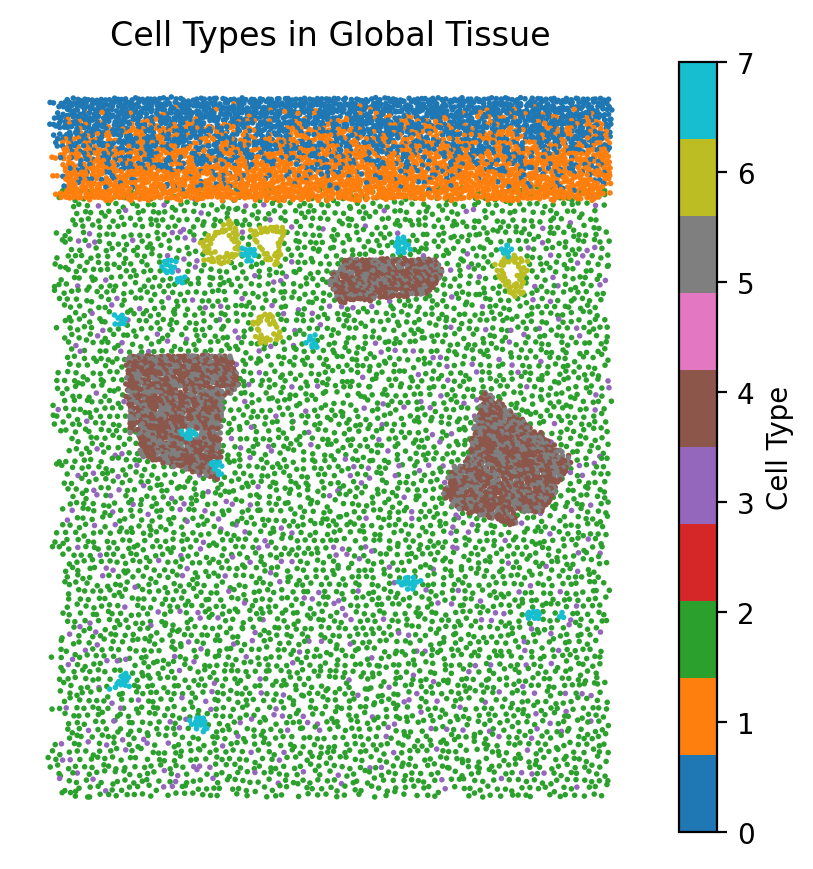

In [8]:
cell_df_global = pd.read_csv('output_skin/ground_truths/global_ground_truth_cells.csv')
dots_df_global = pd.read_csv('output_skin/ground_truths/global_ground_truth_dots.csv')

plt.figure(figsize=(5, 5), dpi=200)
plt.scatter(cell_df_global['X'], cell_df_global['Y'], c=cell_df_global['Class ID'], cmap='tab10', s=1)
plt.colorbar(label='Cell Type')
plt.title('Cell Types in Global Tissue')
plt.axis('off')
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.show()

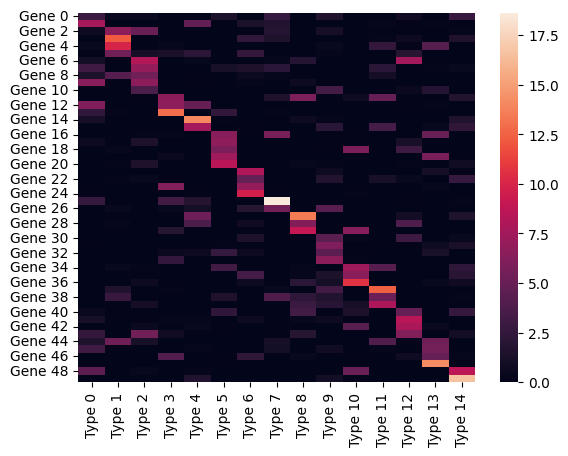

In [7]:
import seaborn as sns
sns.heatmap(cell_type_df);

In [12]:
cell_type_df

,Type 0,Type 1,Type 2,Type 3,Type 4,Type 5,Type 6,Type 7,Type 8,Type 9,Type 10,Type 11,Type 12,Type 13,Type 14
Gene 0,2.867572,0.531889,0.463007,0.000000,0.038974,1.315854,0.070681,2.634101,0.000000,1.649281,0.000000,0.000000,0.731113,0.000000,2.730549
Gene 1,7.644304,0.011528,0.001753,0.000000,4.793551,0.000000,1.311303,1.723208,0.005385,0.000000,0.000000,0.244291,0.129586,0.217958,0.091418
Gene 2,0.630910,6.534997,5.094897,0.000000,0.057356,0.000000,0.137626,1.828051,0.000000,1.159549,0.000000,0.000000,0.114132,0.001199,0.241567
Gene 3,0.004190,12.206990,0.000000,0.044252,0.002268,0.000000,2.450715,1.508768,0.000000,0.000000,0.000000,0.147662,0.601033,0.005500,1.535350
Gene 4,0.392952,9.919725,0.000000,0.293809,0.000000,0.000000,0.000000,0.030199,0.000000,0.364668,0.000000,2.522954,0.086708,4.183593,0.000000
Gene 5,0.001227,5.411792,1.074368,1.268251,2.118082,0.000000,2.491072,0.007706,0.000000,0.255588,0.000000,0.000000,1.926568,0.000000,0.000000
Gene 6,0.961409,0.000000,8.167562,0.000000,0.324900,0.000000,0.000000,0.234261,1.859996,0.000000,0.000000,0.000000,7.608876,0.118517,0.005134
Gene 7,3.096957,0.000000,6.941811,0.000000,0.000000,1.214525,1.413194,2.056141,0.001852,0.000000,0.000000,2.048917,0.070160,0.182629,0.421303
Gene 8,1.449054,4.211694,5.452724,0.000000,0.117326,0.001815,0.574619,0.270981,0.001342,0.005211,0.000000,1.074578,0.000000,0.000988,0.000000
Gene 9,6.374220,0.000000,6.607568,0.000000,0.130009,0.000000,0.252030,0.000000,0.596483,0.000000,0.043432,0.000000,0.001178,0.000000,0.000000
